In [1]:
!nvidia-smi

Mon Mar  9 01:11:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   55C    P8             14W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch, math, time
import numpy as np
import matplotlib.pyplot as plt

assert torch.cuda.is_available()
device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
print("Torch:", torch.__version__)

GPU: NVIDIA L4
Torch: 2.10.0+cu128


In [3]:
class CUDATimer:
    def __init__(self):
        self.start = torch.cuda.Event(enable_timing=True)
        self.end = torch.cuda.Event(enable_timing=True)

    def time_ms(self, fn, iters=100, warmup=20):
        # Warmup
        for _ in range(warmup):
            fn()
        torch.cuda.synchronize()

        self.start.record()
        for _ in range(iters):
            fn()
        self.end.record()
        torch.cuda.synchronize()

        return self.start.elapsed_time(self.end) / iters  # ms / iter

In [4]:
def measure_peak_bandwidth(dtype=torch.float32, target_gib=2.0, iters=200, warmup=50):
    """
    Returns (best_GBps, used_bytes_per_iter, N_elements)
    target_gib: approximate tensor size per input (GiB). We'll allocate A, B, C each ~target_gib.
    """
    timer = CUDATimer()

    # figure out how many bytes we can allocate safely
    free_bytes, total_bytes = torch.cuda.mem_get_info()
    # We'll allocate 3 tensors (A,B,C) + slack
    max_alloc = int(free_bytes * 0.80)
    bytes_per_tensor = int(min(target_gib * (1024**3), max_alloc // 3))

    element_size = torch.tensor([], dtype=dtype).element_size()
    N = bytes_per_tensor // element_size
    # round down to a multiple for nicer alignment
    N = (N // 256) * 256
    if N <= 0:
        raise RuntimeError("Not enough free GPU memory for the requested target size.")

    A = torch.randn(N, device=device, dtype=dtype)
    B = torch.randn(N, device=device, dtype=dtype)
    C = torch.empty(N, device=device, dtype=dtype)

    def op():
        # out-of-place add so we count a write
        torch.add(A, B, out=C)

    ms = timer.time_ms(op, iters=iters, warmup=warmup)

    # Traffic model (bytes): read A + read B + write C
    bytes_per_iter = 3 * N * element_size
    GBps = (bytes_per_iter / (ms / 1e3)) / 1e9  # bytes/sec -> GB/s (10^9)
    return GBps, bytes_per_iter, N

for dt in [torch.float32, torch.float16]:
    bw, bpi, N = measure_peak_bandwidth(dtype=dt, target_gib=1.0)
    print(dt, "BW(GB/s):", bw, "| N:", N, "| bytes/iter:", bpi)

torch.float32 BW(GB/s): 232.82149320414237 | N: 268435456 | bytes/iter: 3221225472
torch.float16 BW(GB/s): 233.48186426257564 | N: 536870912 | bytes/iter: 3221225472


In [5]:
def measure_peak_gemm_tflops(dtype=torch.float16, sizes=(4096, 6144, 8192), iters=50, warmup=10, use_tf32=True):
    """
    Measures GEMM throughput for square matmuls: (n,n)@(n,n).
    Returns best_TFLOPs and a dict of size->TFLOPs.
    """
    timer = CUDATimer()

    # TF32 only applies to float32 matmul on Ampere+
    torch.backends.cuda.matmul.allow_tf32 = bool(use_tf32)

    results = {}
    best = 0.0

    for n in sizes:
        # guard memory
        element_size = torch.tensor([], dtype=dtype).element_size()
        bytes_needed = 3 * (n*n*element_size)  # A, B, C approx
        free_bytes, _ = torch.cuda.mem_get_info()
        if bytes_needed > free_bytes * 0.7:
            print(f"Skipping n={n} (not enough free mem).")
            continue

        A = torch.randn((n, n), device=device, dtype=dtype)
        B = torch.randn((n, n), device=device, dtype=dtype)

        # one matmul
        def op():
            torch.matmul(A, B)

        ms = timer.time_ms(op, iters=iters, warmup=warmup)
        t = ms / 1e3  # seconds

        # FLOPs for GEMM ~ 2*n^3
        flops = 2.0 * (n**3)
        tflops = (flops / t) / 1e12

        results[n] = tflops
        best = max(best, tflops)

        # free some memory between runs
        del A, B
        torch.cuda.empty_cache()

    return best, results

best_tc, per_size = measure_peak_gemm_tflops(dtype=torch.float16, sizes=(4096, 6144, 8192))
print("Best FP16 GEMM TFLOPs:", best_tc)
print("Per size:", per_size)

Best FP16 GEMM TFLOPs: 59.193278005455966
Per size: {4096: 53.609890372913455, 6144: 59.193278005455966, 8192: 51.7847268776334}


In [6]:
best_fp32_tf32, _ = measure_peak_gemm_tflops(dtype=torch.float32, sizes=(2048, 3072, 4096), use_tf32=True)
best_fp32_no, _   = measure_peak_gemm_tflops(dtype=torch.float32, sizes=(2048, 3072, 4096), use_tf32=False)

print("Best float32 GEMM w/ TF32 allowed:", best_fp32_tf32)
print("Best float32 GEMM TF32 disabled:", best_fp32_no)

Best float32 GEMM w/ TF32 allowed: 37.5514043245028
Best float32 GEMM TF32 disabled: 12.138065461952406


In [7]:
def roofline_curve(oi, peak_tflops, peak_gbps):
    """
    oi: FLOP/byte
    peak_tflops: TFLOP/s
    peak_gbps: GB/s
    Returns TFLOP/s roofline value at each oi.
    """
    # bandwidth line: P = OI * BW
    # BW in GB/s = 1e9 B/s, so OI*BW gives FLOP/s; convert to TFLOP/s by /1e12
    bw_tflops = oi * (peak_gbps * 1e9) / 1e12
    return np.minimum(peak_tflops, bw_tflops)

def plot_roofline(peak_gbps, peak_tflops_list, labels, oi_min=1e-3, oi_max=1e3):
    oi = np.logspace(np.log10(oi_min), np.log10(oi_max), 400)

    plt.figure(figsize=(8,6))
    for peak_tflops, lab in zip(peak_tflops_list, labels):
        y = roofline_curve(oi, peak_tflops, peak_gbps)
        plt.loglog(oi, y, label=f"{lab} (peak {peak_tflops:.2f} TFLOP/s)")
    # also show bandwidth slope line alone for reference
    bw_line = oi * (peak_gbps * 1e9) / 1e12
    plt.loglog(oi, bw_line, linestyle="--", label=f"Bandwidth slope (peak {peak_gbps:.1f} GB/s)")

    plt.xlabel("Operational Intensity (FLOP / byte)")
    plt.ylabel("Performance (TFLOP / s)")
    plt.title("Attainable Roofline (measured)")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()

Peak attainable bandwidth (GB/s): 238.0200765901324
Peak FP16 GEMM TFLOPs: 55.06691343388189
Peak TF32-allowed float32 GEMM TFLOPs: 26.464835955969964
Peak strict FP32 GEMM TFLOPs: 12.027150925538681


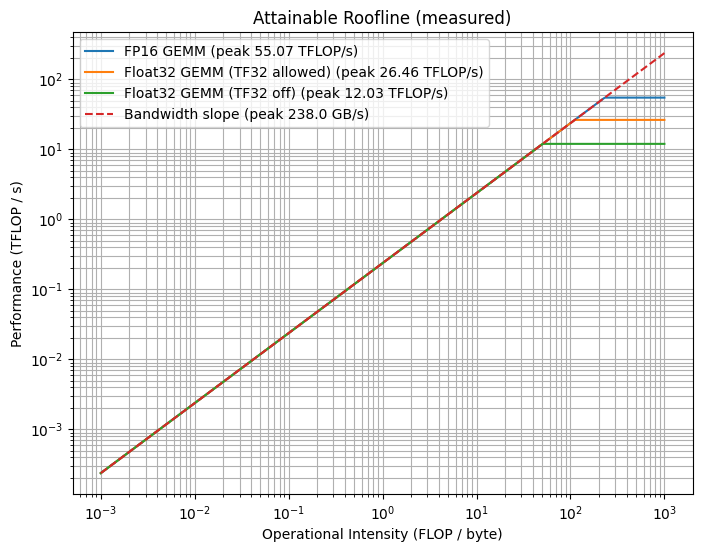

In [8]:
# 1) measure BW
bw32, _, _ = measure_peak_bandwidth(dtype=torch.float32, target_gib=1.0)
bw16, _, _ = measure_peak_bandwidth(dtype=torch.float16, target_gib=1.0)
peak_gbps = max(bw32, bw16)
print("Peak attainable bandwidth (GB/s):", peak_gbps)

# 2) measure compute peaks
peak_fp16, _ = measure_peak_gemm_tflops(dtype=torch.float16, sizes=(4096, 6144, 8192))
peak_tf32, _ = measure_peak_gemm_tflops(dtype=torch.float32, sizes=(2048, 3072, 4096), use_tf32=True)
peak_fp32, _ = measure_peak_gemm_tflops(dtype=torch.float32, sizes=(2048, 3072, 4096), use_tf32=False)

print("Peak FP16 GEMM TFLOPs:", peak_fp16)
print("Peak TF32-allowed float32 GEMM TFLOPs:", peak_tf32)
print("Peak strict FP32 GEMM TFLOPs:", peak_fp32)

plot_roofline(
    peak_gbps=peak_gbps,
    peak_tflops_list=[peak_fp16, peak_tf32, peak_fp32],
    labels=["FP16 GEMM", "Float32 GEMM (TF32 allowed)", "Float32 GEMM (TF32 off)"],
    oi_min=1e-3,
    oi_max=1e3
)